# **Пересдача по СтатОИВ (Бустинг)**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [37]:
df = pd.read_csv("data/Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [39]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

Сводка выбросов (IQR + Z>3):
                      n  n_out_iqr  n_out_z  n_out_any  pct_out_any
col                                                                
age               20000          0        0          0          0.0
study_hours       20000          0        0          0          0.0
class_attendance  20000          0        0          0          0.0
sleep_hours       20000          0        0          0          0.0

Строк с любым числовым выбросом: 0 (0.00%)


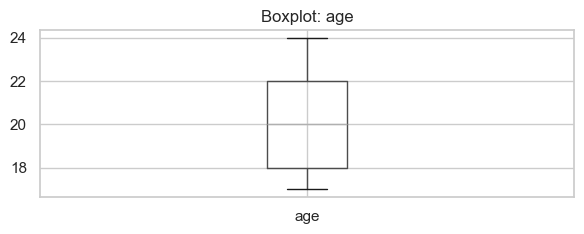

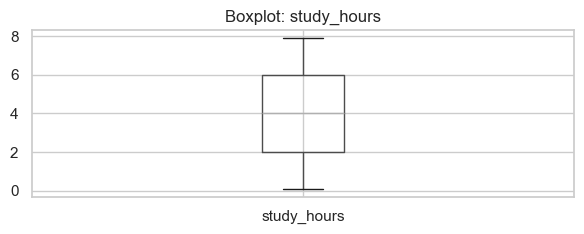

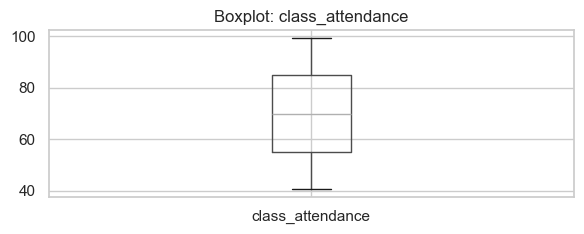

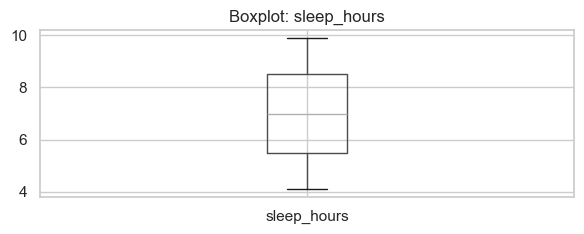

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_clean = df.copy()

num_cols = ["student_id", "age", "study_hours", "class_attendance", "sleep_hours"]
num_cols_clean = [c for c in num_cols if c in df_clean.columns and c != "student_id"]


summary = []
outlier_masks = {}

for col in num_cols_clean:
    col_series = df_clean[col]
    s = col_series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_iqr = (col_series < lower) | (col_series > upper)

    mean = s.mean()
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        mask_z = pd.Series(False, index=col_series.index)
    else:
        mask_z = (np.abs((col_series - mean) / std) > 3)

    mask_any = mask_iqr | mask_z
    outlier_masks[col] = mask_any

    summary.append({
        "col": col,
        "n": len(col_series),
        "n_out_iqr": int(mask_iqr.sum()),
        "n_out_z": int(mask_z.sum()),
        "n_out_any": int(mask_any.sum()),
        "pct_out_any": round(100 * mask_any.sum() / len(col_series), 2)
    })

summary_df = pd.DataFrame(summary).set_index("col").sort_values("pct_out_any", ascending=False)
print("Сводка выбросов (IQR + Z>3):")
print(summary_df)

for col in summary_df.index:
    if summary_df.loc[col, "n_out_any"] == 0:
        continue
    print(f"\nПримеры выбросов по '{col}' (top 5):")
    display(df_clean.loc[outlier_masks[col], [col, "exam_score"]].sort_values(col, ascending=False).head(5))

df_clean["_is_outlier_any"] = np.column_stack([outlier_masks[c] for c in num_cols_clean]).any(axis=1)
print(f"\nСтрок с любым числовым выбросом: {df_clean['_is_outlier_any'].sum()} "
      f"({df_clean['_is_outlier_any'].mean()*100:.2f}%)")

for col in num_cols_clean:
    plt.figure(figsize=(6,2.5))
    df_clean.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()


# **Comparison of models**

In [42]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_clean = df.copy()

cat_cols = [
    "gender", "course", "internet_access",
    "sleep_quality", "study_method",
    "facility_rating", "exam_difficulty"
]

num_cols = ["student_id", "age", "study_hours", "class_attendance", "sleep_hours"]

le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df_clean[c] = le.fit_transform(df_clean[c].astype(str))
    le_dict[c] = le

X_all = df_clean.drop(columns=["exam_score"])
y = df_clean["exam_score"]

X_all = X_all.drop(columns=["student_id"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

y_cls = pd.qcut(df_clean["exam_score"], q=3, labels=[0,1,2]).astype(int)
X_clf = X_all.copy()
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("reg:", X_train.shape, X_test.shape, "clf:", X_train_c.shape, X_test_c.shape)


reg: (16000, 11) (4000, 11) clf: (16000, 11) (4000, 11)


In [43]:
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier,
    AdaBoostRegressor, AdaBoostClassifier
)
from xgboost import XGBRegressor, XGBClassifier

models_reg = {
    "RF": RandomForestRegressor(n_estimators=400, max_depth=12, random_state=42),
    "XGB": XGBRegressor(n_estimators=350, learning_rate=0.05, max_depth=8, subsample=0.9, colsample_bytree=0.9, random_state=42),
    "HGB": HistGradientBoostingRegressor(random_state=42),
    "Ada": AdaBoostRegressor(n_estimators=200, random_state=42)
}
models_clf = {
    "RF": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=8, eval_metric="mlogloss", random_state=42),
    "HGB": HistGradientBoostingClassifier(random_state=42),
    "Ada": AdaBoostClassifier(n_estimators=200, random_state=42)
}


In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score, accuracy_score, confusion_matrix

reg_res, clf_res = [], []
reg_preds, clf_preds = {}, {}

for name, m in models_reg.items():
    try:
        m.fit(X_train, y_train)
        p = m.predict(X_test)
        p = np.clip(p, 0, 100)
        reg_preds[name] = p
        reg_res.append((name, np.sqrt(mean_squared_error(y_test, p)), mean_absolute_error(y_test, p), r2_score(y_test, p)))
    except Exception as e:
        print("reg skip", name, e)

for name, m in models_clf.items():
    try:
        m.fit(X_train_c, y_train_c)
        p = m.predict(X_test_c)
        clf_preds[name] = p
        clf_res.append((name, accuracy_score(y_test_c, p), f1_score(y_test_c, p, average="macro")))
    except Exception as e:
        print("clf skip", name, e)

reg_df = pd.DataFrame(reg_res, columns=["model","RMSE","MAE","R2"]).set_index("model").sort_values("RMSE")
clf_df = pd.DataFrame(clf_res, columns=["model","accuracy","f1_macro"]).set_index("model").sort_values("f1_macro", ascending=False)


In [45]:
print("Regression results (by RMSE):")
display(reg_df)
print("\nClassification results (by F1_macro):")
display(clf_df)

Regression results (by RMSE):


,RMSE,MAE,R2
model,,,
HGB,9.946732,8.005712,0.723404
XGB,10.240576,8.238362,0.706821
RF,10.382130,8.386167,0.698659
Ada,10.761382,8.787602,0.676242



Classification results (by F1_macro):


,accuracy,f1_macro
model,,
HGB,0.69650,0.697365
Ada,0.69150,0.694341
RF,0.69175,0.692094
XGB,0.68575,0.687046


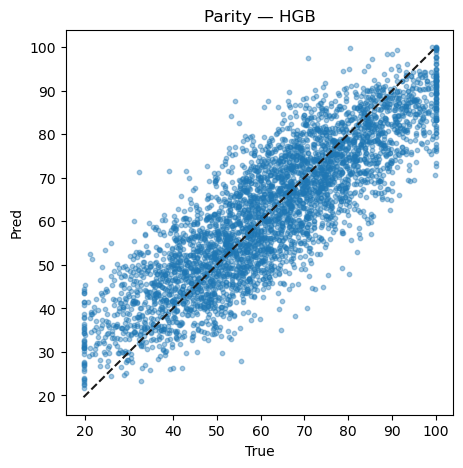

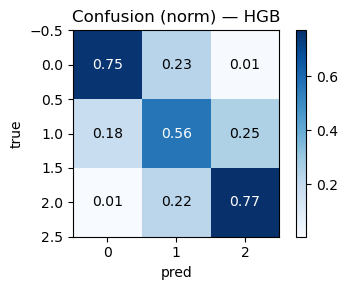

In [46]:
import matplotlib.pyplot as plt
plt.style.use('default')

top_reg = reg_df.index[0]
plt.figure(figsize=(5,5))
plt.scatter(y_test, reg_preds[top_reg], alpha=0.4, s=10)
mn, mx = min(y_test.min(), reg_preds[top_reg].min()), max(y_test.max(), reg_preds[top_reg].max())
plt.plot([mn,mx],[mn,mx],"k--"); plt.xlabel("True"); plt.ylabel("Pred"); plt.title(f"Parity — {top_reg}"); plt.show()

top_clf = clf_df.index[0]
cm = confusion_matrix(y_test_c, clf_preds[top_clf], labels=sorted(y_test_c.unique()))
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(4,3)); plt.imshow(cmn, cmap=plt.cm.Blues); plt.title(f"Confusion (norm) — {top_clf}")
plt.colorbar(); plt.xlabel("pred"); plt.ylabel("true")
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j,i,f"{cmn[i,j]:.2f}",ha="center",va="center", color="white" if cmn[i,j]>0.5 else "black")
plt.tight_layout(); plt.show()
